#### Impact of Hypothesis 1 violations on the completeness of Algorithm 2 (Corollary 2)

For each run we compute the oracle $\theta_{\mathcal{G}}=\min\{\theta\in\mathcal{G}:B_{\delta/J}(\theta)\le r^*\}$
and the threshold returned by Algorithm 2, and call the run complete when the two coincide. Runs
where $\Theta=\emptyset$ are not counted, Corollary 2 assuming $\Theta\neq\emptyset$. Both sides read
off the same bound path, so unlike the validity of the guarantee this is directly testable.

In [1]:
%run -i ../python_scripts/nb_setup.py
from joblib import cpu_count

c:\Users\Emilien JEMELEN\Documents\SGR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### We measure H1 violations with % of discordant pairs (% of sample pairs $((x_1,y_1),(x_2,y_2))$, s.t. $[L(f(x_1),y_1)< L(f(x_2),y_2)] \cap [\kappa_f(x_1)\le \kappa_f(x_2)]$)

% discordant pairs in our settings

In [2]:
cifar_set = pickle.load(open("../experiments/CIFAR/sgp_set_cnn", "rb"))
wsi_set = pickle.load(open("../experiments/WSI/sgp_set_cnn", "rb"))
chest_set = pickle.load(open("../experiments/CHEST/sgp_set_densenet_SR", "rb"))
diabetes_set = pickle.load(open("../experiments/DIABETES/sgp_set_tabular_SR", "rb"))

tab = discordance_table(
    {"CIFAR": cifar_set, "WSI": wsi_set, "CHEST": chest_set, "DIABETES": diabetes_set}
)
tab.pivot(index="dataset", columns="loss", values="discordance_pct").round(2)

loss,L_01,L_FN,L_FP
dataset,,,
CHEST,15.78,45.08,14.79
CIFAR,23.20,27.75,23.83
DIABETES,34.61,44.07,33.83
WSI,11.09,16.63,11.18


#### We simulate many beta mixture datasets, with __random imbalance__ and different parametrizations of RANKING ($\kappa_f$) impact on error ($\Rightarrow$ discordance levels)

Then we measure the percentage of runs of Algorithm 2 yielding the best reachable threshold on grid $\mathcal{G}$ : this is _% of completeness._

In [3]:
METRICS = ["standard", "FPR", "FNR"]
THETA_MIN, THETA_MAX = 0, 1
RANKINGS = [
    0,
    0.01,
    0.02,
    0.05,
    0.07,
    0.1,
    0.3,
    0.5,
    0.7,
    0.9,
    1.1,
    1.5,
    2,
    3,
    6,
    np.inf,
]
SIZES = np.arange(500, 53000, 2000)
NUM_SEEDS = 500
R_STARS = [0.05, 0.1, 0.15]
N_CPUS = int(4 * cpu_count() / 5)

In [4]:
tasks = [(n, r, s) for n in SIZES for r in RANKINGS for s in range(NUM_SEEDS)]
chunks = Parallel(n_jobs=N_CPUS)(
    delayed(run_one)(n, r, s, METRICS, R_STARS, THETA_MIN, THETA_MAX, DELTA)
    for n, r, s in tasks
)

res = pd.DataFrame([rec for c in chunks for rec in c])
res["discordant"] = 100 * (1 - res.auc_emp)
# NaN on the uncounted runs, so groupby means are taken among non-empty Theta
res["complete"] = np.where(res.status.eq("empty"), np.nan, res.status.eq("exact"))

In [11]:
cnt = res.groupby(["metric", "n", "r_star", "ranking"]).complete.transform("size")
res = res.loc[
    cnt >= 300
]  # at least 300 runs with output out of the 500, otherwise not significant

In [12]:
cols = ["discordant", "complete"]
display(res.groupby(["metric", "r_star"])[cols].mean().round(4))

discordant  complete
metric   r_star                      
FNR      0.05        9.3839    0.9881
         0.10       11.6972    0.9830
         0.15       12.8034    0.9801
FPR      0.05        9.3841    0.9879
         0.10       11.6268    0.9827
         0.15       12.8219    0.9796
standard 0.05        9.9394    0.9915
         0.10       12.4018    0.9887
         0.15       12.9647    0.9892

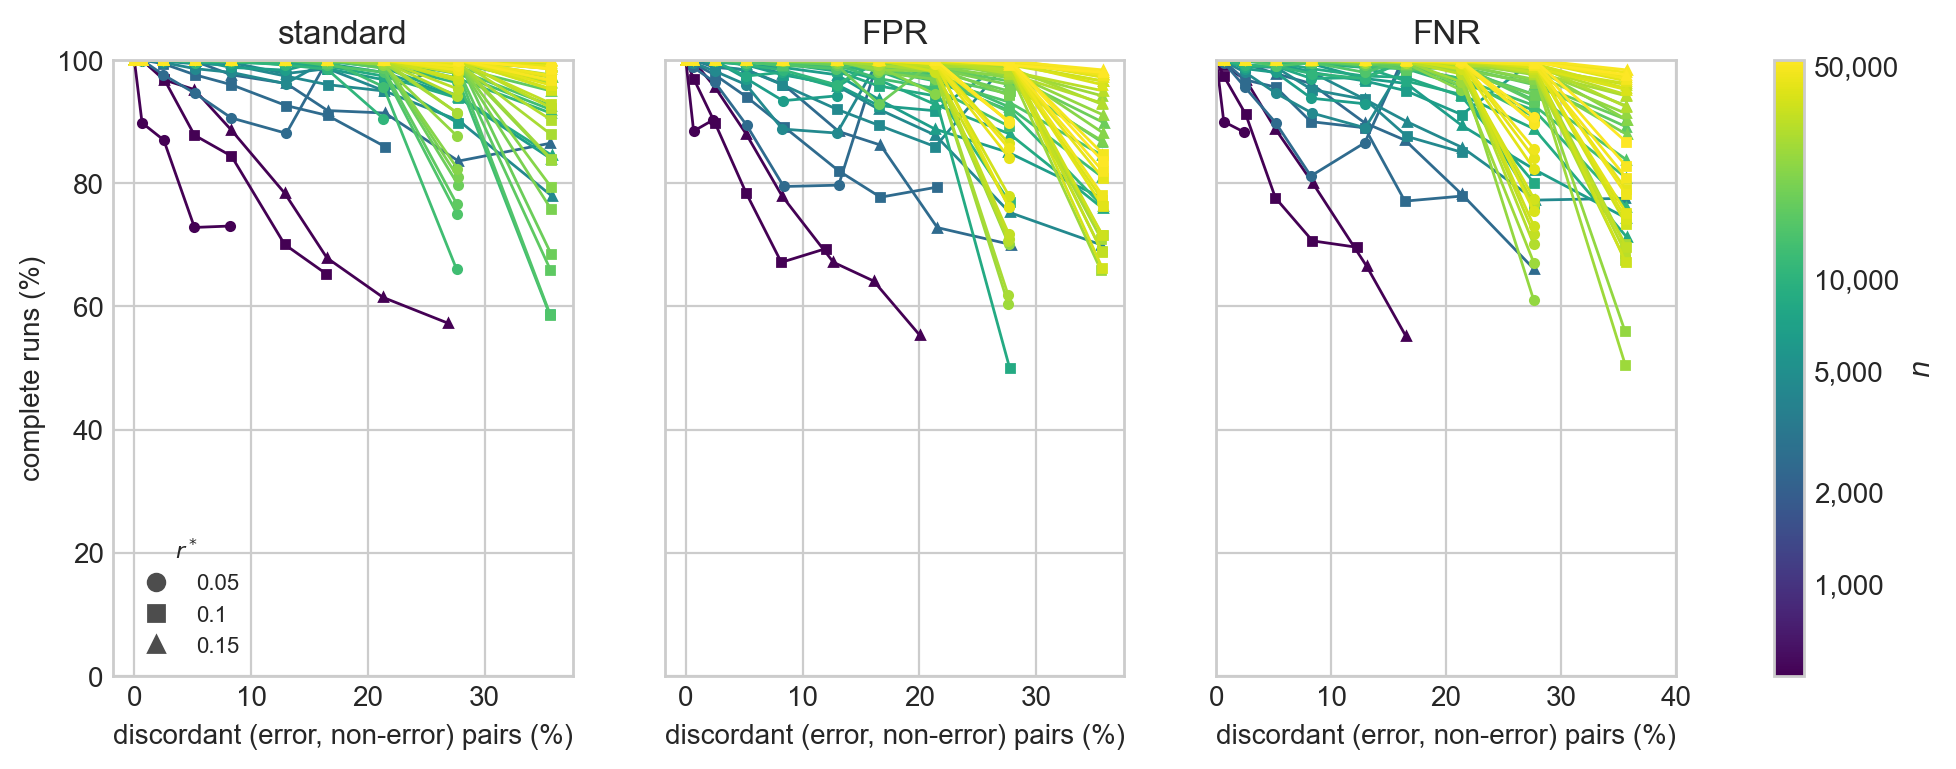

In [ ]:
agg = (
    res.groupby(["metric", "n", "r_star", "ranking"], as_index=False)[
        ["discordant", "complete"]
    ]
    .mean()
    .dropna()
)

agg = agg.loc[agg.complete > 0.4]

ns = sorted(agg.n.unique())
r_stars = sorted(agg.r_star.unique())
MARKERS = dict(zip(r_stars, ["o", "s", "^", "D", "v", "P"]))
cnorm, cmap = LogNorm(vmin=min(ns), vmax=max(ns)), plt.cm.viridis

with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, axes = plt.subplots(
        1, len(METRICS), figsize=(4.2 * len(METRICS), 4), dpi=200, sharey=True
    )
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, METRICS):
        for (n, r_star), g in agg[agg.metric == metric].groupby(["n", "r_star"]):
            g = g.sort_values("discordant")
            ax.plot(
                g.discordant,
                100 * g.complete,
                marker=MARKERS[r_star],
                ms=3,
                lw=1.0,
                color=cmap(cnorm(n)),
            )
        ax.set_xlabel("discordant (error, non-error) pairs (%)")
        ax.set_title(metric)
    axes[0].set_ylabel("complete runs (%)")
    axes[0].legend(
        handles=[
            Line2D([], [], marker=MARKERS[r], ls="none", color="0.3", label=f"{r}")
            for r in r_stars
        ],
        title="$r^*$",
        fontsize=8,
        title_fontsize=8,
    )
    ticks = [t for t in [1000, 2000, 5000, 10000, 50000] if min(ns) <= t <= max(ns)]
    cbar = fig.colorbar(ScalarMappable(norm=cnorm, cmap=cmap), ax=axes, ticks=ticks)
    cbar.ax.minorticks_off()
    cbar.ax.set_yticklabels([f"{t:,}" for t in ticks])
    cbar.set_label("$n$")
    plt.ylim(0, 100)
    plt.xlim(0, 40)
    plt.show()

With the % discordance observed on our datasets, Algorithm 2 yields more than xxx% complete runs in every $(r^*,n)$ configuration. 
Bigger value of $n$ clearly increases the % of complete runs.